### Troubleshooting

In [1]:
import torch
import torchio as tio
import yaml
import matplotlib.pyplot as plt

from pkg.data.datasets import ADNIDataset, TransformDataset
from pkg.data.datamodules import ADNIDataModule
from pkg.utils.instantiate import instantiate
from pkg.models.poe import PoE
from pkg.data.augmentation import build_augmentation
from torch.utils.data import DataLoader, Subset

from pkg.models.poe import PoE
from torch.nn import CrossEntropyLoss

from itertools import combinations

import numpy as np

/home/cestari/.conda/envs/adni_rcc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("./config.yaml", "r") as f:
    cfg = yaml.load(f, yaml.Loader)

print(cfg)

{'datamodule': {'class': 'pkg.data.datamodules.ADNIDataModule', 'args': {'data': {'data_dir': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/data/', 'scan_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/dataset_multimodal.csv', 'diagnostic_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/DXSUM_02Feb2026.csv', 'diagnosis': [1, 2, 3], 'tolerance': 180, 'modalities': {'PET-FBB': ['PET-FBB']}}, 'split': {'mode': 'kfold', 'seed': 42, 'folds': 5, 'test_size': 0.1, 'val_size': 0.2}, 'loader': {'batch_size': 4, 'weighted_sampling': False, 'shuffle': True}, 'transform': [{'random_flip': {'p': 0.5}}, {'random_affine': {'p': 0.5, 'degrees': 5, 'translation': 5}}, {'random_noise': {'p': 0.2, 'std': [0, 0.1]}}, {'random_blur': {'p': 1, 'std': 0.8}}]}}, 'model': {'class': 'pkg.models.poe.PoE', 'args': {'n_modalities': 1, 'n_classes': 3}}, 'optimizer': {'name': 'AdamW', 'params

In [3]:
dm = instantiate(cfg["datamodule"])
dm.setup()

Matching scans to diagnoses...
Verifying scans available in dir...
Creating multimodal samples...


In [4]:
dm.set_fold(0)

In [7]:
model = PoE(3, 1)

counts = np.bincount(dm.train_labels)
weights = (1.0 / counts)
weights = weights/weights.sum()
w = torch.tensor(weights, dtype=torch.float32)

criterion = CrossEntropyLoss(weight=w)
criterion.reduction = "none"

model.set_criterion(criterion)

In [8]:
weights

array([0.34759838, 0.20052373, 0.45187789])

In [9]:


for batch in dm.train_dataloader(1):

    mask = batch["mask"]
    X = batch["X"]
    y = batch["y"]

    #print(X.shape)
    #print(y.shape)

    loss, out = model.train_batch(batch, 1)
    print(f"Loss {loss.item()} ")
    
    #break
    # out = {}

    # loss = 0
    
    # for r in range(1, n_modalities+1):
    #     for combo in combinations([ i for i in range(n_modalities)], r):

    #         # Mask samples with all modalities available 
    #         current_mask = torch.prod(mask[ :, combo], dim=1)

    #         print(f" Current mask: {current_mask}")

    #         print(f"Forward {model(X, combo) }")
            
    #         # Compute masked loss
    #         l = criterion( model(X, combo), y)
    #         l = ( l*current_mask ).sum()/current_mask.sum()

    #         print(f" l : {l}")

    #         # Save loss to output dict
    #         out[ "loss_" + "".join([ str(c) for c in combo])] = l.item()

    #         # Add to total
    #         loss += l
    
    break

Loss 1.0988216400146484 


### Test

In [1]:
import yaml

from pkg.data.datasets import ADNIDataset
from pkg.data.datamodules import ADNIDataModule

from pkg.utils.instantiate import instantiate

import matplotlib.pyplot as plt

/home/cestari/.conda/envs/adni_rcc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("./config.yaml", "r") as f:
    cfg = yaml.load(f, yaml.Loader)

print(cfg)

{'datamodule': {'class': 'pkg.data.datamodules.ADNIDataModule', 'args': {'data': {'data_dir': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/data/', 'scan_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/dataset_multimodal.csv', 'diagnostic_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/DXSUM_02Feb2026.csv', 'diagnosis': [1, 2, 3], 'tolerance': 180, 'modalities': {'PET-amyloid': ['PET-AV45', 'PET-NAV4694', 'PET-FBB'], 'PET-tau': ['PET-AV1451', 'PET-MK6240', 'PET-PI2620']}}, 'split': {'mode': 'kfold', 'seed': 42, 'folds': 5, 'test_size': 0.1, 'val_size': 0.2}, 'loader': {'batch_size': 4, 'weighted_sampling': False, 'shuffle': True}, 'transform': [{'random_flip': {'p': 0.5}}, {'random_affine': {'p': 0.5, 'degrees': 5, 'translation': 5}}, {'random_noise': {'p': 0.2, 'std': [0, 0.1]}}, {'random_blur': {'p': 1, 'std': 0.8}}]}}, 'model': {'class': 'pkg.models.poe.PoE'

In [6]:
dm = instantiate(cfg["datamodule"])
dm.setup()

Matching scans to diagnoses...
Verifying scans available in dir...
Creating multimodal samples...


In [7]:
dm.ds.df_multimodal

,PET-FBB,diagnosis,subject_id,strat_key,label
0,I1594117,1.0,006_S_4485,11,0
1,I1594205,1.0,006_S_6209,11,0
2,I1610460,1.0,006_S_6209,11,0
3,I10939874,1.0,006_S_6209,11,0
4,I1594133,1.0,006_S_6234,11,0
...,...,...,...,...,...
962,I1614548,1.0,941_S_7051,11,0
963,I10936211,2.0,941_S_7051,21,1
964,I1614614,1.0,941_S_7074,11,0
965,I10311819,1.0,941_S_7074,11,0


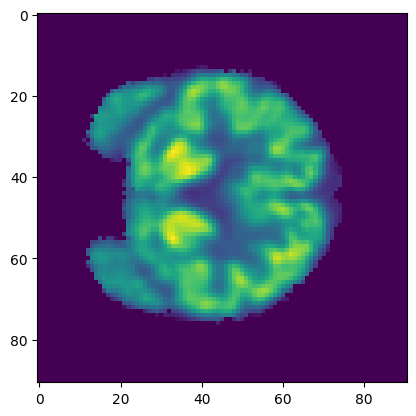

In [10]:

index = 70
diag = dm.ds[index]["y"]
sample = dm.ds[index]["X"]

plt.imshow(sample[0,:,70,:])


In [63]:
print(diag)

tensor(1)


tensor(2)


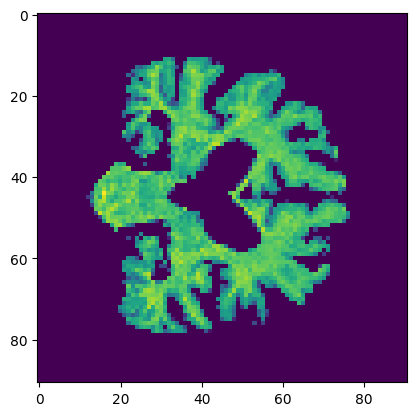

In [66]:
index = 34
diag = dm.ds[index]["y"]
sample = dm.ds[index]["X"]

print(diag)
plt.imshow(sample[0,:,50,:])

In [58]:
print(diag)

tensor(0)


tensor(0)


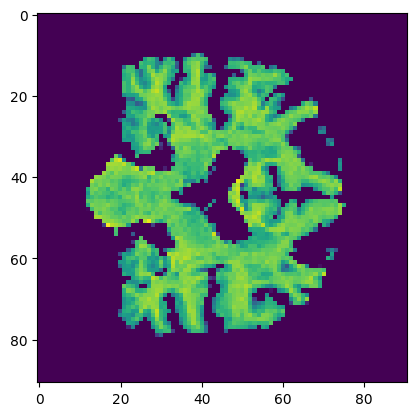

In [64]:
index = 40
diag = dm.ds[index]["y"]
sample = dm.ds[index]["X"]

print(diag)
plt.imshow(sample[0,:,50,:])

### Troubleshooting 2 

In [1]:
import yaml
import matplotlib.pyplot as plt

from pkg.training.criterion import build_criterion
from pkg.training.optimizer import build_optimizer
from pkg.utils.instantiate import instantiate
from pkg.data.datamodules import ADNITestDataModule
from pkg.training.trainer import Trainer

/home/cestari/.conda/envs/adni_rcc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("./configs/config2.yaml", "r") as f:
    cfg = yaml.load(f, yaml.Loader)

print(cfg)

{'datamodule': {'class': 'pkg.data.datamodules.ADNITestDataModule', 'args': {'complete_only': True, 'data': {'data_dir': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/data/', 'scan_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/dataset_multimodal.csv', 'diagnostic_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/DXSUM_02Feb2026.csv', 'diagnosis': [1, 2, 3], 'tolerance': 180, 'modalities': {'PET-amyloid': ['PET-AV45', 'PET-NAV4694', 'PET-FBB'], 'PET-fdg': ['PET-FDG'], 'MRI': ['MRI-T1-1.5T', 'MRI-T1-3T']}}, 'split': {'mode': 'kfold', 'seed': 42, 'folds': 5, 'test_size': 0.15, 'val_size': 0.1}, 'loader': {'batch_size': 4, 'weighted_sampling': False, 'shuffle': True}, 'transform': [{'random_flip': {'p': 0.5}}, {'random_affine': {'p': 0.5, 'degrees': 5, 'translation': 5}}, {'random_noise': {'p': 0.2, 'std': [0, 0.1]}}, {'random_blur': {'p': 1, 'std': 0.8}}]}}, 'mode

In [3]:
dm = instantiate(cfg["datamodule"])
dm.setup()
dm.info()

Matching scans to diagnoses...
Verifying scans available in dir...
Creating multimodal samples...


#      % Stratification Keys Distribution                  \
                                                   1011010 1101010 3101010   
Fold 0 Train  1014  0.803                            0.256   0.003   0.005   
       Val     249  0.197                            0.257     NaN   0.012   
Fold 1 Train  1013  0.802                            0.250   0.002   0.008   
       Val     250  0.198                            0.284   0.004     NaN   
Fold 2 Train  1000  0.792                            0.260   0.003   0.006   
       Val     263  0.208                            0.243     NaN   0.008   
Fold 3 Train  1011  0.800                            0.256   0.003   0.007   
       Val     252  0.200                            0.258     NaN   0.004   
Fold 4 Train  1014  0.803                            0.260   0.001   0.006   
       Val     249  0.197                            0.241   0.008   0.008   
Test           210  1.000                            0.333   0.005     NaN   

                                                              
             3011010 2011010 2010110 3010110 2101010 1010110  
Fold 0 Train   0.150   0.473   0.082   0.027   0.003   0.001  
       Val     0.177   0.474   0.044   0.028   0.004   0.004  
Fold 1 Train   0.162   0.476   0.070   0.028   0.003   0.002  
       Val     0.128   0.464   0.092   0.024   0.004     NaN  
Fold 2 Train   0.156   0.469   0.073   0.027   0.004   0.002  
       Val     0.152   0.490   0.080   0.027     NaN     NaN  
Fold 3 Train   0.155   0.472   0.075   0.027   0.003   0.002  
       Val     0.155   0.480   0.071   0.028   0.004     NaN  
Fold 4 Train   0.153   0.477   0.072   0.027   0.003   0.001  
       Val     0.165   0.458   0.084   0.028   0.004   0.004  
Test           0.133   0.429   0.067   0.019   0.014     NaN

<Axes: ylabel='Frequency'>

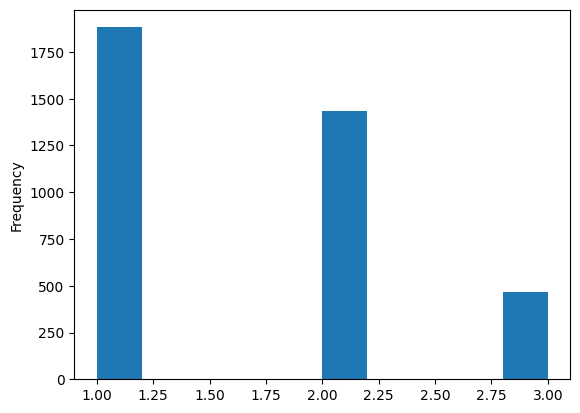

In [26]:
dm.ds.df_multimodal["diagnosis"].plot.hist()

In [8]:
dm.set_fold(0)

In [5]:
model = instantiate(cfg["model"])
callbacks = instantiate(cfg["callbacks"])
criterion = build_criterion(cfg["criterion"], train_labels=dm.train_labels) 
optim = build_optimizer(cfg["optimizer"], model.parameters())

model.set_criterion(criterion)

# Build trainer 
trainer = Trainer(model, optim, dm, callbacks, dir="./test", **cfg["trainer"])

In [1]:

def show_sample(index, modality=0):
    sample = dm.ds[index]
    X = sample["X"]
    y = sample["y"]
    key = sample["key"]

    print(key)
    plt.imshow(X[modality,0,:,40,:])
    plt.show()

show_sample(80, modality=0)


NameError: name 'dm' is not defined

### Mental scores 

In [34]:
import pandas as pd 
import yaml 
from pkg.data.datamodules import ADNIDataModule
from pkg.utils.diagnosis_matching import match_diagnosis

In [35]:
with open("./configs/config2.yaml", "r") as f:
    cfg = yaml.load(f, yaml.Loader)

print(cfg)

{'datamodule': {'class': 'pkg.data.datamodules.ADNITestDataModule', 'args': {'complete_only': True, 'data': {'data_dir': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/data/', 'scan_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/dataset_multimodal.csv', 'diagnostic_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/DXSUM_02Feb2026.csv', 'diagnosis': [1, 2, 3], 'tolerance': 180, 'modalities': {'PET-fdg': ['PET-FDG'], 'MRI': ['MRI-T1-1.5T', 'MRI-T1-3T']}}, 'split': {'mode': 'kfold', 'seed': 42, 'folds': 5, 'test_size': 0.15, 'val_size': 0.1}, 'loader': {'batch_size': 16, 'weighted_sampling': False, 'shuffle': True}, 'transform': [{'random_flip': {'p': 0.5}}, {'random_affine': {'p': 0.5, 'degrees': 5, 'translation': 5}}, {'random_noise': {'p': 0.2, 'std': [0, 0.1]}}, {'random_blur': {'p': 1, 'std': 0.8}}]}}, 'model': {'class': 'pkg.models.poe.PoE', 'args': {'n_modali

In [36]:
dm = instantiate(cfg["datamodule"])
dm.setup()
dm.info()

Matching scans to diagnoses...
Verifying scans available in dir...
Creating multimodal samples...


#      % Stratification Keys Distribution                \
                                                      1011   1101   3101   
Fold 0 Train  1539  0.788                            0.183  0.084  0.096   
       Val     415  0.212                            0.159  0.120  0.070   
Fold 1 Train  1545  0.791                            0.177  0.089  0.090   
       Val     409  0.209                            0.181  0.103  0.093   
Fold 2 Train  1577  0.807                            0.178  0.099  0.093   
       Val     377  0.193                            0.180  0.064  0.082   
Fold 3 Train  1584  0.811                            0.179  0.097  0.088   
       Val     370  0.189                            0.176  0.073  0.100   
Fold 4 Train  1571  0.804                            0.174  0.091  0.086   
       Val     383  0.196                            0.196  0.097  0.110   
Test           313  1.000                            0.173  0.083  0.061   

                                   
               3011   2011   2101  
Fold 0 Train  0.121  0.365  0.151  
       Val    0.106  0.364  0.181  
Fold 1 Train  0.120  0.364  0.159  
       Val    0.110  0.364  0.149  
Fold 2 Train  0.119  0.354  0.157  
       Val    0.111  0.406  0.156  
Fold 3 Train  0.113  0.364  0.160  
       Val    0.138  0.368  0.146  
Fold 4 Train  0.116  0.375  0.158  
       Val    0.125  0.321  0.151  
Test          0.131  0.361  0.192

In [37]:
df_scan = dm.ds.df_scan
len(df_scan)

23066

In [38]:
mmse_csv = "./data/preprocessing_multimodal/csv/All_Subjects_MMSE_12Mar2026.csv"
adas_csv = "./data/preprocessing_multimodal/csv/All_Subjects_ADAS_12Mar2026.csv"
cdr_csv = "./data/preprocessing_multimodal/csv/All_Subjects_CDR_12Mar2026.csv"

In [ ]:
df_mmse = pd.read_csv(mmse_csv)
df_adas = pd.read_csv(adas_csv)
df_cdr = pd.read_csv(cdr_csv)

df_mmse["VISDATE"] = pd.to_datetime(df_mmse["VISDATE"])
df_adas["VISDATE"] = pd.to_datetime(df_adas["VISDATE"])
df_cdr["VISDATE"] = pd.to_datetime(df_cdr["VISDATE"])

tolerance=180

In [ ]:
to_concat = []

for subj in df_scan["subject_id"].unique(): 

    # Get subject visits and scans
    subj_vis = df_mmse[df_mmse["PTID"] == subj].copy()
    subj_scans = df_scan[df_scan["subject_id"] == subj].copy()

    # Drop NaN values
    subj_vis = subj_vis.dropna(subset=["exam_date"])
    subj_scans = subj_scans.dropna(subset=["image_date"])
    
    # Merge_asof requires sorting by the key
    subj_vis = subj_vis.sort_values("exam_date")
    subj_scans = subj_scans.sort_values("image_date")

    # Match nearest withing tolerance
    nearest = pd.merge_asof(
        subj_scans,
        subj_vis[["exam_date", "diagnosis"]],
        left_on="image_date",
        right_on="exam_date",
        direction="nearest",
        tolerance=pd.Timedelta(days=tolerance),
    )

    # Get matched and append to list
    matched = nearest[nearest["diagnosis"].notna()].copy()

    matched = matched[ cols_to_keep ]  

    to_concat.append(matched)

    # Matched ids
    matched_ids = set(matched["image_id"])

    # If all scans matched, continue
    if len(matched_ids) == len(subj_scans):
        continue